# 02. Chạy thuật toán ECLAT và đánh giá

Notebook này dùng dữ liệu đã tiền xử lý để chạy thuật toán ECLAT, sinh tập phổ biến, sinh luật kết hợp và đánh giá bằng `support`, `confidence`, `lift`.

Mục tiêu của phần này là giữ đúng phạm vi đồ án: chứng minh thuật toán chạy được trên dữ liệu giao dịch thực, đọc được kết quả chính và rút ra nhận xét có ý nghĩa từ các luật mua kèm.

## 1. Chuẩn bị môi trường

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    candidates += [
        start / "Data-Mining-Group-7",
        start / "Project" / "Data-Mining-Group-7",
        Path.home() / "Desktop" / "Project" / "Data-Mining-Group-7",
    ]

    for path in candidates:
        path = path.resolve()
        if (path / "src" / "eclat.py").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Khong tim thay project root. Hay mo notebook tu thu muc Data-Mining-Group-7.")

project_root = find_project_root(Path.cwd().resolve())
os.chdir(project_root)

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from association_rules import (
    generate_association_rules,
    load_frequent_itemsets,
    save_association_rules,
    write_summary,
)
from eclat import mine_frequent_itemsets, resolve_min_support_count, save_frequent_itemsets
from utils import load_transactions

print(f"Project root: {project_root}")

Project root: C:\Users\Thanh Nhan\Desktop\Project\Data-Mining-Group-7


## 2. Khai báo tham số

- `MIN_SUPPORT = 0.02`: một itemset phải xuất hiện trong ít nhất 2% số giao dịch. Với dữ liệu hiện tại, ngưỡng này tương đương khoảng 400 giao dịch, đủ để tránh các mẫu quá hiếm.
- `MIN_CONFIDENCE = 0.5`: giữ các luật mà vế phải xảy ra trong ít nhất 50% trường hợp khi vế trái xuất hiện.
- `MIN_LIFT = 1.0`: chỉ giữ các luật có quan hệ đồng xuất hiện tốt hơn mức ngẫu nhiên.

In [2]:
TRANSACTIONS_PATH = Path("data/processed/transactions_cleaned.csv")
FREQUENT_ITEMSETS_PATH = Path("results/frequent_itemsets.csv")
RULES_PATH = Path("results/association_rules.csv")
SUMMARY_PATH = Path("results/eclat_summary.md")
SENSITIVITY_PATH = Path("results/threshold_sensitivity.csv")
FIGURES_DIR = Path("results/figures")

MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.5
MIN_LIFT = 1.0
MAX_SIZE = None

FREQUENT_ITEMSETS_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Đọc dữ liệu giao dịch

Phần mining đọc trực tiếp từ `transactions_cleaned.csv` thay vì tách chuỗi trong `baskets.csv`. Cách này giữ nguyên tên sản phẩm gốc, kể cả trường hợp mô tả sản phẩm có dấu phẩy.

In [3]:
transactions = load_transactions(TRANSACTIONS_PATH)
basket_sizes = [len(items) for _, items in transactions]
unique_items = sorted({item for _, items in transactions for item in items})

dataset_overview = pd.DataFrame(
    [
        [len(transactions), len(unique_items), min(basket_sizes), max(basket_sizes), sum(basket_sizes) / len(basket_sizes)]
    ],
    columns=["transactions", "unique_items", "min_basket_size", "max_basket_size", "avg_basket_size"],
)
dataset_overview

,transactions,unique_items,min_basket_size,max_basket_size,avg_basket_size
0,19952,4042,1,1105,25.918454


## 4. Chạy thuật toán ECLAT

ECLAT chuyển dữ liệu từ dạng ngang sang dạng dọc `item -> TID-list`. Khi ghép các item, thuật toán giao các TID-list để tính nhanh số giao dịch chứa itemset đó.

In [4]:
frequent_itemsets, metadata = mine_frequent_itemsets(
    baskets=transactions,
    min_support=MIN_SUPPORT,
    max_size=MAX_SIZE,
)

save_frequent_itemsets(frequent_itemsets, FREQUENT_ITEMSETS_PATH)

metadata

{'transaction_count': 19952,
 'unique_item_count': 4042,
 'min_support': 0.02,
 'min_support_count': 400,
 'max_size': None,
 'frequent_itemset_count': 376}

## 5. Frequent itemsets nổi bật

In [5]:
frequent_df = pd.read_csv(FREQUENT_ITEMSETS_PATH)
frequent_df.head(15)

,itemset,itemset_size,support_count,support
0,WHITE HANGING HEART T-LIGHT HOLDER,1,2260,0.113272
1,JUMBO BAG RED RETROSPOT,1,2092,0.104852
2,REGENCY CAKESTAND 3 TIER,1,1989,0.099689
3,PARTY BUNTING,1,1686,0.084503
4,LUNCH BAG RED RETROSPOT,1,1564,0.078388
5,ASSORTED COLOUR BIRD ORNAMENT,1,1455,0.072925
6,SET OF 3 CAKE TINS PANTRY DESIGN,1,1385,0.069417
7,PACK OF 72 RETROSPOT CAKE CASES,1,1320,0.066159
8,LUNCH BAG BLACK SKULL.,1,1273,0.063803
9,NATURAL SLATE HEART CHALKBOARD,1,1249,0.062600


In [6]:
top_combo_df = frequent_df[frequent_df["itemset_size"] >= 2].head(10)
top_combo_df

,itemset,itemset_size,support_count,support
61,JUMBO BAG RED RETROSPOT | JUMBO BAG PINK POLKADOT,2,825,0.041349
71,ROSES REGENCY TEACUP AND SAUCER | GREEN REGENC...,2,768,0.038492
82,JUMBO BAG RED RETROSPOT | JUMBO STORAGE BAG SUKI,2,724,0.036287
100,JUMBO BAG RED RETROSPOT | JUMBO SHOPPER VINTAG...,2,680,0.034082
116,LUNCH BAG RED RETROSPOT | LUNCH BAG BLACK SKULL.,2,641,0.032127
117,ALARM CLOCK BAKELIKE RED | ALARM CLOCK BAKELIK...,2,640,0.032077
118,GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY...,2,633,0.031726
133,LUNCH BAG RED RETROSPOT | LUNCH BAG PINK POLKADOT,2,606,0.030373
139,ROSES REGENCY TEACUP AND SAUCER | PINK REGENCY...,2,599,0.030022
145,JUMBO BAG RED RETROSPOT | JUMBO BAG BAROQUE B...,2,585,0.029320


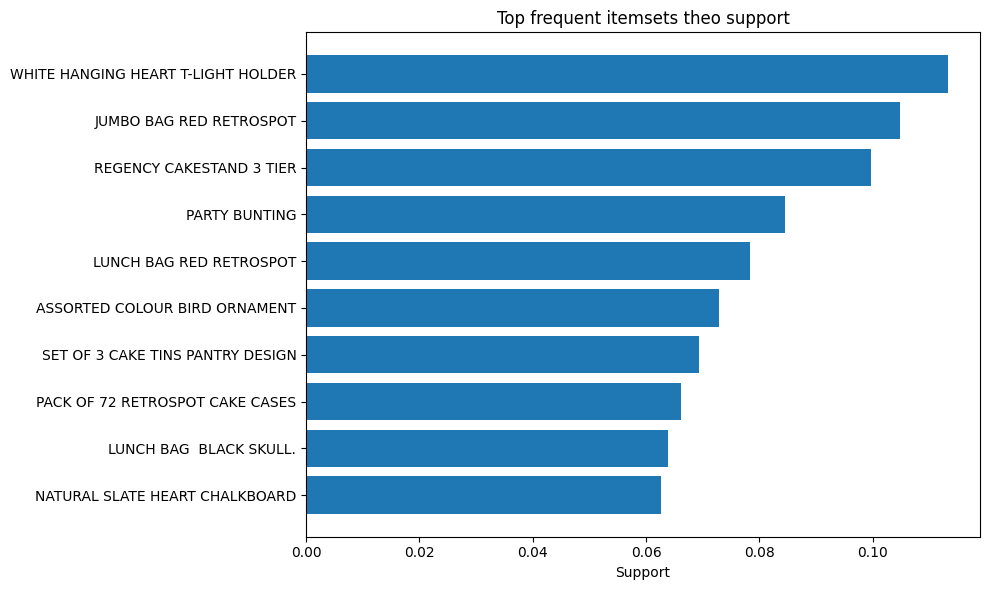

In [7]:
top_itemsets = frequent_df.head(10).sort_values("support", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets["itemset"], top_itemsets["support"])
plt.xlabel("Support")
plt.title("Top frequent itemsets theo support")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_frequent_itemsets.png", dpi=160)
plt.show()

## 6. Sinh luật kết hợp

Từ các itemset phổ biến có kích thước từ 2 trở lên, ta sinh luật dạng `A -> B` và tính:

- `support(A -> B)`: tỷ lệ giao dịch chứa cả A và B.
- `confidence(A -> B)`: xác suất mua B khi đã mua A.
- `lift(A -> B)`: mức tăng xác suất mua B khi biết A so với xác suất mua B trung bình.

In [9]:
rules = generate_association_rules(
    frequent_itemsets=frequent_itemsets,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
    transaction_count=metadata["transaction_count"],
)

save_association_rules(rules, RULES_PATH)
write_summary(
    frequent_itemsets=frequent_itemsets,
    rules=rules,
    metadata=metadata,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
    output_path=SUMMARY_PATH,
)

print(f"So luat thoa nguong: {len(rules):,}")
print(f"Da luu frequent itemsets tai: {FREQUENT_ITEMSETS_PATH}")
print(f"Da luu association rules tai: {RULES_PATH}")
print(f"Da luu ket luan tai: {SUMMARY_PATH}")

So luat thoa nguong: 60
Da luu frequent itemsets tai: results\frequent_itemsets.csv
Da luu association rules tai: results\association_rules.csv
Da luu ket luan tai: results\eclat_summary.md


## 7. Đọc các luật theo nhiều góc nhìn

In [10]:
rules_df = pd.read_csv(RULES_PATH)
rules_df.head(10)

,antecedent,consequent,antecedent_size,consequent_size,support_count,support,antecedent_support,consequent_support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER | GREEN REGENC...,1,2,542,0.027165,0.038392,0.038492,0.707572,18.382126
1,ROSES REGENCY TEACUP AND SAUCER | GREEN REGENC...,PINK REGENCY TEACUP AND SAUCER,2,1,542,0.027165,0.038492,0.038392,0.705729,18.382126
2,ROSES REGENCY TEACUP AND SAUCER | PINK REGENCY...,GREEN REGENCY TEACUP AND SAUCER,2,1,542,0.027165,0.030022,0.050872,0.904841,17.786597
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER | PINK REGENCY...,1,2,542,0.027165,0.050872,0.030022,0.533990,17.786597
4,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,1,1,633,0.031726,0.038392,0.050872,0.826371,16.244088
5,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,1,1,633,0.031726,0.050872,0.038392,0.623645,16.244088
6,GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY...,ROSES REGENCY TEACUP AND SAUCER,2,1,542,0.027165,0.031726,0.053428,0.856240,16.025988
7,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY...,1,2,542,0.027165,0.053428,0.031726,0.508443,16.025988
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,1,1,546,0.027366,0.037991,0.045760,0.720317,15.741246
9,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,1,1,546,0.027366,0.045760,0.037991,0.598028,15.741246


In [11]:
rules_df.sort_values(["lift", "confidence", "support"], ascending=False).head(10)[
    ["antecedent", "consequent", "support", "confidence", "lift"]
]

,antecedent,consequent,support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER | GREEN REGENC...,0.027165,0.707572,18.382126
1,ROSES REGENCY TEACUP AND SAUCER | GREEN REGENC...,PINK REGENCY TEACUP AND SAUCER,0.027165,0.705729,18.382126
2,ROSES REGENCY TEACUP AND SAUCER | PINK REGENCY...,GREEN REGENCY TEACUP AND SAUCER,0.027165,0.904841,17.786597
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER | PINK REGENCY...,0.027165,0.533990,17.786597
4,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031726,0.826371,16.244088
5,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031726,0.623645,16.244088
6,GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY...,ROSES REGENCY TEACUP AND SAUCER,0.027165,0.856240,16.025988
7,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY...,0.027165,0.508443,16.025988
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027366,0.720317,15.741246
9,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.027366,0.598028,15.741246


In [ ]:
rules_df.sort_values(["support", "confidence", "lift"], ascending=False).head(10)[
    ["antecedent", "consequent", "support", "confidence", "lift"]
]

Các luật có `lift` cao cho thấy quan hệ giữa hai vế mạnh hơn ngẫu nhiên. Tuy nhiên khi áp dụng thực tế, không nên chỉ nhìn `lift`: luật có `support` cao thường đáng tin hơn vì xuất hiện trên nhiều giao dịch hơn.

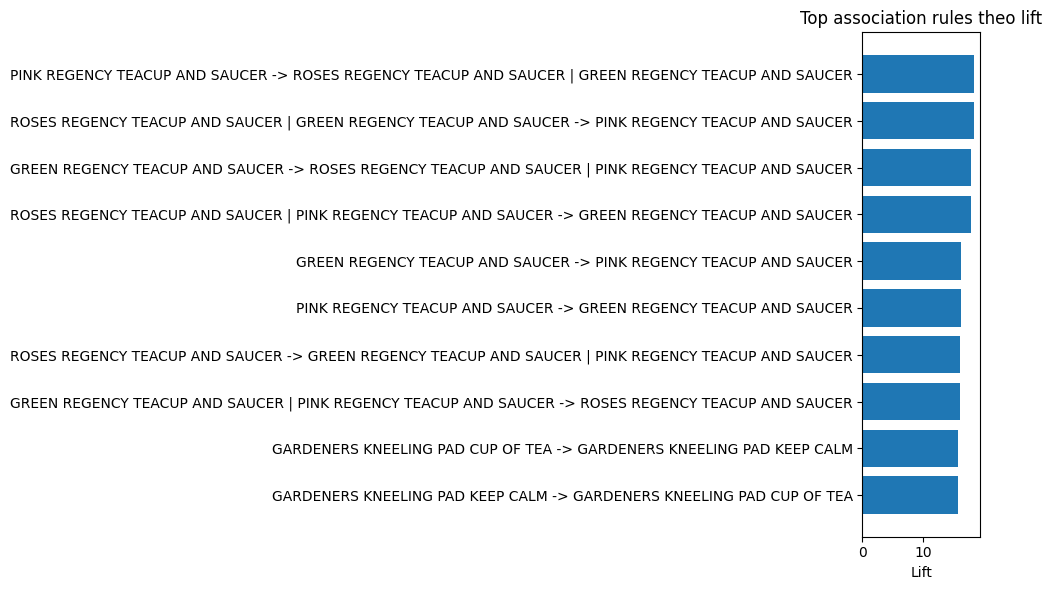

In [12]:
top_rules = rules_df.sort_values(["lift", "confidence", "support"], ascending=False).head(10).copy()
top_rules["rule"] = top_rules["antecedent"] + " -> " + top_rules["consequent"]
top_rules = top_rules.sort_values("lift", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_rules["rule"], top_rules["lift"])
plt.xlabel("Lift")
plt.title("Top association rules theo lift")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_association_rules.png", dpi=160)
plt.show()

## 8. Thử nghiệm độ nhạy theo ngưỡng support

Bảng dưới đây giúp giải thích vì sao chọn `min_support = 0.02`. Ngưỡng thấp hơn tạo ra nhiều itemsets và rules hơn, nhưng cũng dễ có các mẫu hiếm. Ngưỡng cao hơn chạy nhanh và gọn hơn, nhưng có thể bỏ sót các quan hệ mua kèm có ý nghĩa.

In [13]:
support_values = [0.015, 0.02, 0.025, 0.03]
sensitivity_rows = []

for support_value in support_values:
    itemsets_i, metadata_i = mine_frequent_itemsets(
        baskets=transactions,
        min_support=support_value,
        max_size=3,
    )
    rules_i = generate_association_rules(
        frequent_itemsets=itemsets_i,
        min_confidence=MIN_CONFIDENCE,
        min_lift=MIN_LIFT,
        transaction_count=metadata_i["transaction_count"],
    )
    sensitivity_rows.append(
        {
            "min_support": support_value,
            "min_support_count": metadata_i["min_support_count"],
            "frequent_itemsets": len(itemsets_i),
            "association_rules": len(rules_i),
            "top_lift": max([rule["lift"] for rule in rules_i], default=0),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(SENSITIVITY_PATH, index=False)
sensitivity_df

,min_support,min_support_count,frequent_itemsets,association_rules,top_lift
0,0.015,300,699,174,37.539815
1,0.020,400,376,60,18.382126
2,0.025,499,223,37,18.382126
3,0.030,599,140,13,16.244088


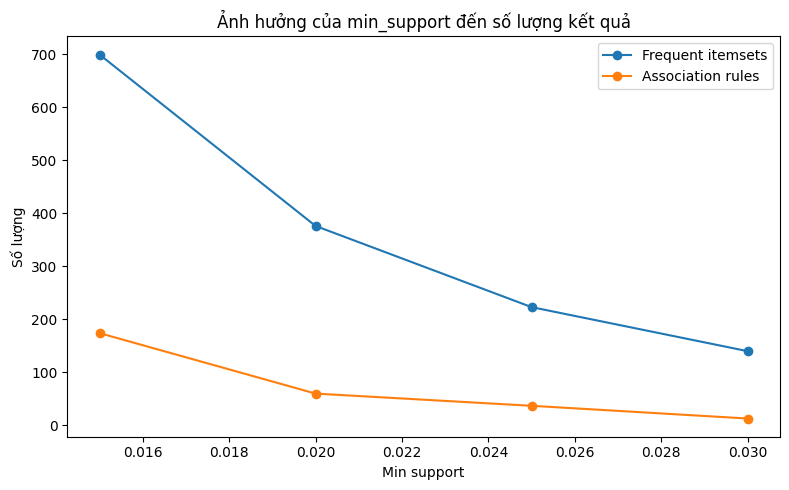

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(sensitivity_df["min_support"], sensitivity_df["frequent_itemsets"], marker="o", label="Frequent itemsets")
plt.plot(sensitivity_df["min_support"], sensitivity_df["association_rules"], marker="o", label="Association rules")
plt.xlabel("Min support")
plt.ylabel("Số lượng")
plt.title("Ảnh hưởng của min_support đến số lượng kết quả")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "support_sensitivity.png", dpi=160)
plt.show()

## 9. Kết luận cho báo cáo

Với `min_support = 0.02`, kết quả đủ gọn để phân tích nhưng vẫn giữ được các quan hệ mua kèm rõ ràng. Các nhóm sản phẩm cùng dòng thiết kế hoặc cùng công dụng xuất hiện nổi bật, ví dụ nhóm `REGENCY TEACUP AND SAUCER`, `JUMBO BAG`, `LUNCH BAG`.

Một số luật có `lift` rất cao cho thấy quan hệ đồng xuất hiện mạnh, nhưng khi đề xuất ứng dụng thực tế nên ưu tiên thêm yếu tố `support`. Ví dụ luật liên quan đến `JUMBO BAG PINK POLKADOT -> JUMBO BAG RED RETROSPOT` có support cao hơn, phù hợp để gợi ý bán kèm hoặc đặt sản phẩm gần nhau. Nhóm `REGENCY TEACUP AND SAUCER` có lift cao, phù hợp hơn cho combo theo bộ sưu tập.

Kết quả không khẳng định quan hệ nhân quả giữa các sản phẩm, mà chỉ cho thấy các mẫu đồng xuất hiện trong dữ liệu giao dịch. Đây là phạm vi phù hợp với bài toán khai phá tập phổ biến và luật kết hợp.

In [15]:
print(SUMMARY_PATH.read_text(encoding="utf-8"))

# Ket luan thuc nghiem ECLAT

## Tham so chay
- So transaction: 19952
- So item rieng biet: 4042
- Min support: 0.02 (400 transaction)
- Min confidence: 0.5
- Min lift: 1.0

## Ket qua chinh
- So frequent itemsets tim duoc: 376
- So association rules thoa nguong: 60
- Item pho bien nhat: WHITE HANGING HEART T-LIGHT HOLDER (support = 11.33%, 2260 transaction).
- Tap item di cung nhau pho bien nhat: JUMBO BAG RED RETROSPOT | JUMBO BAG PINK POLKADOT (support = 4.13%, 825 transaction).
- Luat co lift cao nhat: ROSES REGENCY TEACUP AND SAUCER | GREEN REGENCY TEACUP AND SAUCER -> PINK REGENCY TEACUP AND SAUCER (confidence = 70.57%, lift = 18.38).
- Luat co support lon nhat: JUMBO BAG PINK POLKADOT -> JUMBO BAG RED RETROSPOT (support = 4.13%, confidence = 67.73%, lift = 6.46).

## Nhan xet
Ket qua cho thay cac san pham thuoc cung dong thiet ke hoac cung muc dich su dung co xu huong xuat hien chung trong gio hang. Cac luat co lift > 1 nghia la viec mua tien de lam tang xac suat mua ket qua so 